<a href="https://colab.research.google.com/github/Naveen-gale/DATA-SCENS-LEARNING/blob/main/emotionanalyses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from datasets import load_dataset

In [6]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [7]:
label_name = emotion_dataset['train'].features['label'].names
label_name

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [8]:
df_train = pd.DataFrame(
    {
        "text": train_text,
        "label": [label_name[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        "text": test_text,
        "label": [label_name[i] for i in test_label]
    }
)

In [9]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [10]:
df_train.isna().sum()

,0
text,0
label,0


In [11]:
df_train.duplicated().sum()

np.int64(1)

In [12]:
df_train.describe()

,text,label
count,16000,16000
unique,15969,6
top,im still not sure why reilly feels the need to...,joy
freq,2,5362


In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


In [14]:
df_train.label.value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


In [15]:
df_train.drop_duplicates(inplace=True)

In [16]:
df_train.duplicated().sum()


np.int64(0)

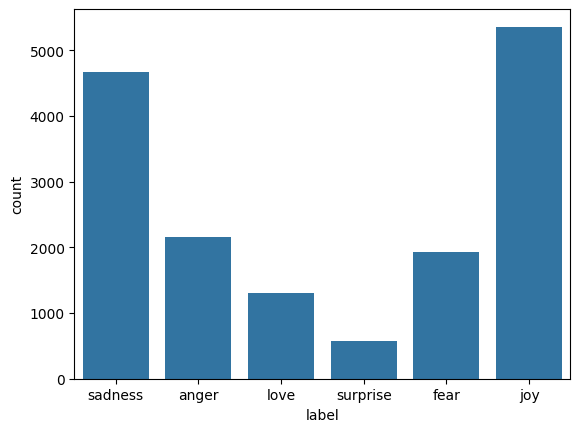

In [23]:
sns.countplot(x='label', order= df_train['label'],  data=df_train)
plt.show()

In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000
max_len = 100


In [36]:
tokenize = Tokenizer(max_words, oov_token='x')
tokenize.fit_on_texts(df_train['text'])
sequences_train = tokenize.texts_to_sequences(df_train['text'])
sequences_test = tokenize.texts_to_sequences(df_test['text'])
sequences_padd_train = pad_sequences(sequences_train, maxlen=max_len)
sequences_padd_test = pad_sequences(sequences_test, maxlen=max_len)


In [37]:
train_label= np.array(train_label)
test_label = np.array(test_label)

In [38]:
train_label

array([0, 0, 3, ..., 1, 3, 0])

In [40]:
num_classes = len(np.unique(train_label))
num_classes


print(f"Vocabulary Size: {len(tokenize.word_index)}")
print(f"Max Sentence Length: {sequences_padd_train.shape[1]}")

Vocabulary Size: 15212
Max Sentence Length: 100
